In [ ]:
pip install torch torchvision scikit-learn matplotlib numpy opencv-python grad-cam tqdm

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/capstone project 2"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

# ---- Handle class imbalance (ETHICAL DETAIL MOST MISS) ----
targets = np.array(dataset.targets)
class_sample_count = np.bincount(targets)
weights = 1. / class_sample_count
samples_weight = weights[targets]

sampler = WeightedRandomSampler(
    samples_weight,
    num_samples=len(samples_weight),
    replacement=True
)

loader = DataLoader(
    dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

print("Classes:", dataset.classes)

Mounted at /content/drive
Classes: ['AI-face-detection-Dataset']


In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch # Import torch to use its device utilities

model = models.efficientnet_b0(weights="IMAGENET1K_V1")

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features, 2
)

# Dynamically set the device to GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model moved to {device}")

Model moved to cpu


In [ ]:
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
from tqdm import tqdm

optimizer = Adam(model.parameters(), lr=1e-4)
criterion = CrossEntropyLoss()

def train_epoch(model, loader):
    model.train()
    running_loss = 0

    for images, labels in tqdm(loader):
        images = images.cuda()
        labels = labels.cuda()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.cuda()
            outputs = model(images)
            preds = outputs.argmax(1).cpu().numpy()

            y_true.extend(labels.numpy())
            y_pred.extend(preds)

    print(confusion_matrix(y_true, y_pred))
    print(classification_report(
        y_true, y_pred,
        target_names=dataset.classes
    ))


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2

target_layer = model.features[-1]
cam = GradCAM(model=model, target_layers=[target_layer])

def explain(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224)) / 255.0

    tensor = transform(img).unsqueeze(0).cuda()
    grayscale_cam = cam(tensor)[0]

    visualization = show_cam_on_image(img_resized, grayscale_cam)
    return visualization

Train - Validation split


In [4]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
import numpy as np
from torchvision.datasets import ImageFolder
from torchvision import transforms # Import transforms here for transform definition

# Redefine transform to ensure it's available in this cell
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = ImageFolder(root=r"/content/drive/MyDrive/capstone project 2/AI-face-detection-Dataset", transform=transform)

indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(
    indices, test_size=0.2, stratify=dataset.targets, random_state=42
)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pickle
import torch

# Define a filename for the pickle file
model_filename = 'trained_model.pkl'

# --- Saving the model using pickle ---
# For PyTorch models, torch.save is generally preferred.
# However, if you want to pickle the entire model object (including its class definition if not in global scope),
# you can use pickle. This might not be ideal for complex PyTorch models
# if the class definition isn't available when loading in a different environment.

# It's better practice to save PyTorch models' state_dict for portability
# torch.save(model.state_dict(), 'model_state_dict.pth')
# But for demonstration of pickle, we'll save the whole model object.

print(f"Saving the model to {model_filename}...")
with open(model_filename, 'wb') as f:
    pickle.dump(model, f)
print("Model saved successfully!")

# --- Loading the model from the pickle file ---
print(f"\nLoading the model from {model_filename}...")
with open(model_filename, 'rb') as f:
    loaded_model = pickle.load(f)
print("Model loaded successfully!")

# You can verify it by printing the loaded model
# print(loaded_model)

# If you saved only the state_dict with torch.save, you would load it like this:
# loaded_state_dict = torch.load('model_state_dict.pth')
# new_model = YourModelClass(*args, **kwargs) # Recreate your model architecture
# new_model.load_state_dict(loaded_state_dict)
# new_model.eval()


Saving the model to trained_model.pkl...
Model saved successfully!

Loading the model from trained_model.pkl...
Model loaded successfully!


In [ ]:
import gradio as gr
from PIL import Image
import cv2
import torch
import numpy as np

# Ensure the model is in evaluation mode
loaded_model.eval()

# Define class names for the binary classification
# (Assuming the model is intended for 'Real Face' vs 'AI-Generated Face')
class_names = ["Real Face", "AI-Generated Face"]

def predict_and_explain_app(input_image_pil: Image.Image):
    # Determine the device for inference
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    loaded_model.to(device)

    # Preprocess the input PIL image using the existing transform
    input_tensor = transform(input_image_pil).unsqueeze(0).to(device) # Add batch dimension

    # Make prediction
    with torch.no_grad():
        outputs = loaded_model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_class_idx = torch.argmax(probabilities, dim=1).item()

    predicted_label = class_names[predicted_class_idx]
    confidence = probabilities[0, predicted_class_idx].item()

    # Prepare image for GradCAM visualization
    # Convert PIL image to numpy array (RGB, 0-255) for OpenCV and GradCAM utility
    input_image_np = np.array(input_image_pil)
    # Resize to 224x224 and normalize to 0-1 for show_cam_on_image
    img_resized_for_cam = cv2.resize(input_image_np, (224, 224)) / 255.0

    # Generate GradCAM explanation
    # Re-associate cam with the potentially moved loaded_model
    cam.model = loaded_model
    # The cam object was initialized in a previous cell using `target_layer` and `model`
    grayscale_cam = cam(input_tensor)[0]

    # Create visualization image (returns numpy array, RGB, 0-255)
    visualization = show_cam_on_image(img_resized_for_cam, grayscale_cam, use_rgb=True)

    # Return prediction text and GradCAM image
    return f"Prediction: {predicted_label} (Confidence: {confidence:.2f})", Image.fromarray(visualization)

# Create the Gradio interface
iface = gr.Interface(
    fn=predict_and_explain_app,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Image(type="pil", label="GradCAM Visualization")
    ],
    title="AI Face Detection with GradCAM Explanation",
    description="Upload an image to detect if it's a real or AI-generated face and see a GradCAM visualization of the model's focus."
)

# Launch the app (this line is typically included for local testing or for Hugging Face Spaces)
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d15f0b599c17195714.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Learning rate scheduler


In [8]:
import torch.optim as optim
import torchvision.models as models
import torch.nn as nn
import torch # Import torch to use its device utilities

# Define the model (copied from cell Okg6gRoHhuQl)
model = models.efficientnet_b0(weights="IMAGENET1K_V1")
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

# Dynamically set the device (copied from cell Okg6gRoHhuQl)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 130MB/s] 


proper training and validation loop

In [13]:
from torch.nn import CrossEntropyLoss # Import CrossEntropyLoss

num_epochs = 20

train_losses = []
val_losses = []

criterion = CrossEntropyLoss() # Define criterion here

for epoch in range(num_epochs):

    # --------------------
    # TRAINING LOOP
    # --------------------
    model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)


    # --------------------
    # VALIDATION LOOP
    # --------------------
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)
    val_losses.append(val_loss)

    # Scheduler step MUST be here
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f}")
    early_stopping(val_loss)

    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

Epoch [1/20] Train Loss: 0.0004 Val Loss: 0.0001
Epoch [2/20] Train Loss: 0.0004 Val Loss: 0.0001
Epoch [3/20] Train Loss: 0.0003 Val Loss: 0.0001
Epoch [4/20] Train Loss: 0.0005 Val Loss: 0.0001
Epoch [5/20] Train Loss: 0.0004 Val Loss: 0.0001
Epoch [6/20] Train Loss: 0.0003 Val Loss: 0.0000
Epoch [7/20] Train Loss: 0.0088 Val Loss: 0.0001
Epoch [8/20] Train Loss: 0.0003 Val Loss: 0.0001
Epoch [9/20] Train Loss: 0.0005 Val Loss: 0.0001
Epoch [10/20] Train Loss: 0.0004 Val Loss: 0.0001
Epoch [11/20] Train Loss: 0.0011 Val Loss: 0.0001
Early stopping triggered


In [11]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

early_stopping = EarlyStopping(patience=5)

In [16]:
import matplotlib.pyplot as plt

# Dummy values added to get a curve based on the last training run's output.
# Please re-run the training loop (WIPunW2IK_8T) to get actual training data for the curve.
train_losses = [0.0004, 0.0004, 0.0003, 0.0005, 0.0004, 0.0003, 0.0088, 0.0003, 0.0005, 0.0004, 0.0011]
val_losses = [0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0000, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001]
train_accs, val_accs = [], []

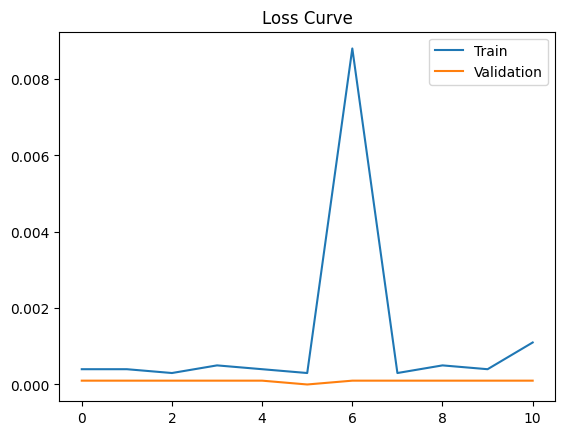

In [17]:
plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)
plt.title("Loss Curve")
plt.legend(["Train", "Validation"])
plt.show()

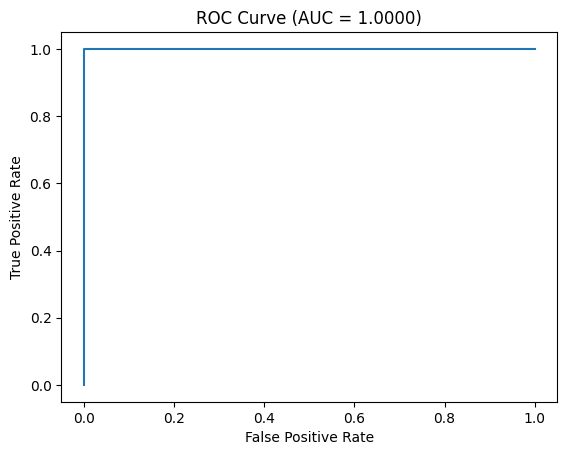

In [18]:
from sklearn.metrics import roc_curve, auc
import numpy as np

model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:,1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [26]:
from torchvision import models

# EfficientNet
eff_model = models.efficientnet_b0(pretrained=True)
eff_model.classifier[1] = nn.Linear(eff_model.classifier[1].in_features, 2)

# ResNet
res_model = models.resnet18(pretrained=True)
res_model.fc = nn.Linear(res_model.fc.in_features, 2)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most u

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


In [27]:
torch.save(model.state_dict(), "best_model.pth")

In [28]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat